In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

# Distribuição do Número Total de Instalações para Autoconsumo em PT

In [37]:
# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')

# Agrupar por 'Distrito' e somar as instalações em cada distrito
tabela_instalacoes = dados.groupby('Distrito')['Número de instalacões'].sum().reset_index()

# Ordenar os distritos por ordem alfabética
tabela_instalacoes = tabela_instalacoes.sort_values(by='Distrito')

# Exibir a tabela final com as duas colunas e distritos ordenados
print(tabela_instalacoes[['Distrito', 'Número de instalacões']])


            Distrito  Número de instalacões
0             Aveiro                 156749
1               Beja                  29478
2              Braga                 238330
3           Bragança                  26987
4     Castelo Branco                  43430
5            Coimbra                 100306
6               Faro                 103039
7             Guarda                  30073
8             Leiria                 124146
9             Lisboa                 227380
10        Portalegre                  20955
11             Porto                 267232
12          Santarém                 121518
13           Setúbal                 189206
14  Viana do Castelo                  51864
15         Vila Real                  46908
16             Viseu                  91185
17             Évora                  34978


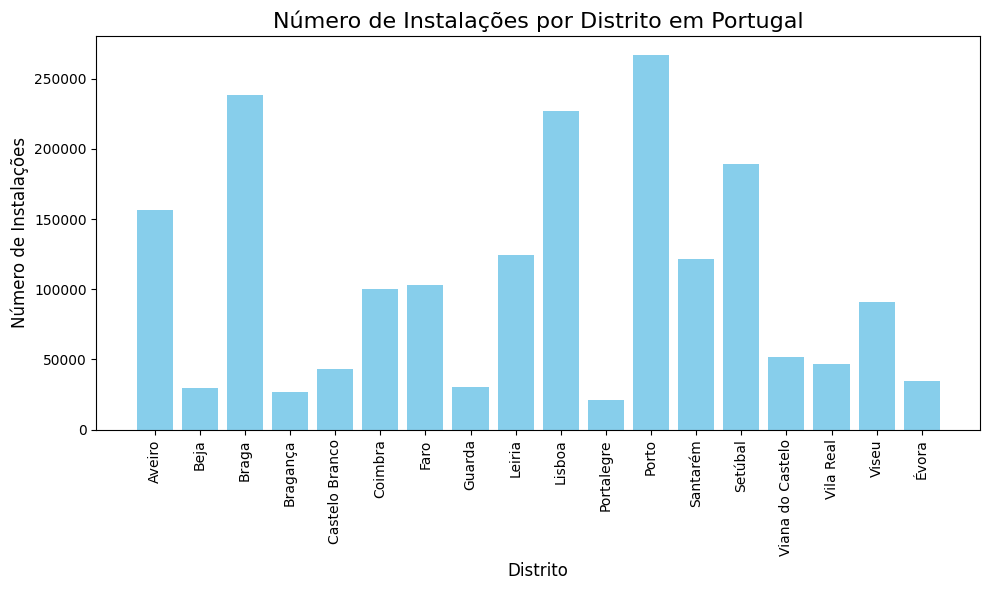

In [38]:
# Criar o gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(tabela_instalacoes['Distrito'], tabela_instalacoes['Número de instalacões'], color='skyblue')

# Adicionar título e rótulos aos eixos
plt.title('Número de Instalações por Distrito em Portugal', fontsize=16)
plt.xlabel('Distrito', fontsize=12)
plt.ylabel('Número de Instalações', fontsize=12)

# Girar os rótulos dos distritos para evitar sobreposição
plt.xticks(rotation=90)

# Exibir o gráfico
plt.tight_layout()  # Ajustar o layout para evitar corte de texto
plt.show()

In [40]:
mapa_pt = gpd.read_file('./pt.json')

# Verifique a coluna 'Distrito' no shapefile
print(mapa_pt.columns)

# Se o nome da coluna for diferente de 'Distrito', ajuste-o
# Exemplo: se a coluna no shapefile for 'NAME_1', renomeie-a para 'Distrito'
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})

# Unir o DataFrame com o shapefile usando a coluna 'Distrito'
mapa_pt = mapa_pt.merge(tabela_instalacoes, on='Distrito', how='left')

# Verifique se a fusão foi feita corretamente
print(mapa_pt.head())

Index(['id', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'VARNAME_1', 'HASC_1',
       'TYPE_1', 'ENGTYPE_1', 'geometry'],
      dtype='object')
     id  ISO    NAME_0  ID_1           Distrito VARNAME_1 HASC_1    TYPE_1  \
0  None  PRT  Portugal  2417      Ilha do Faial            PT.AV  Distrito   
1  None  PRT  Portugal  2417  Ilha de São Jorge            PT.AV  Distrito   
2  None  PRT  Portugal  2417   Ilha da Graciosa            PT.AV  Distrito   
3  None  PRT  Portugal  2417      Ilha Terceira            PT.AV  Distrito   
4  None  PRT  Portugal  2417    Ilha das Flores            PT.AV  Distrito   

  ENGTYPE_1                                           geometry  \
0  District  MULTIPOLYGON (((-12.0354 40.43343, -12.05374 4...   
1  District  MULTIPOLYGON (((-11.356 40.64004, -11.05809 40...   
2  District  MULTIPOLYGON (((-11.28671 40.86463, -11.30802 ...   
3  District  MULTIPOLYGON (((-10.81223 40.64686, -10.82427 ...   
4  District  MULTIPOLYGON (((-12.78519 40.89058, -12.80557 ...   

<Figure size 1200x800 with 0 Axes>

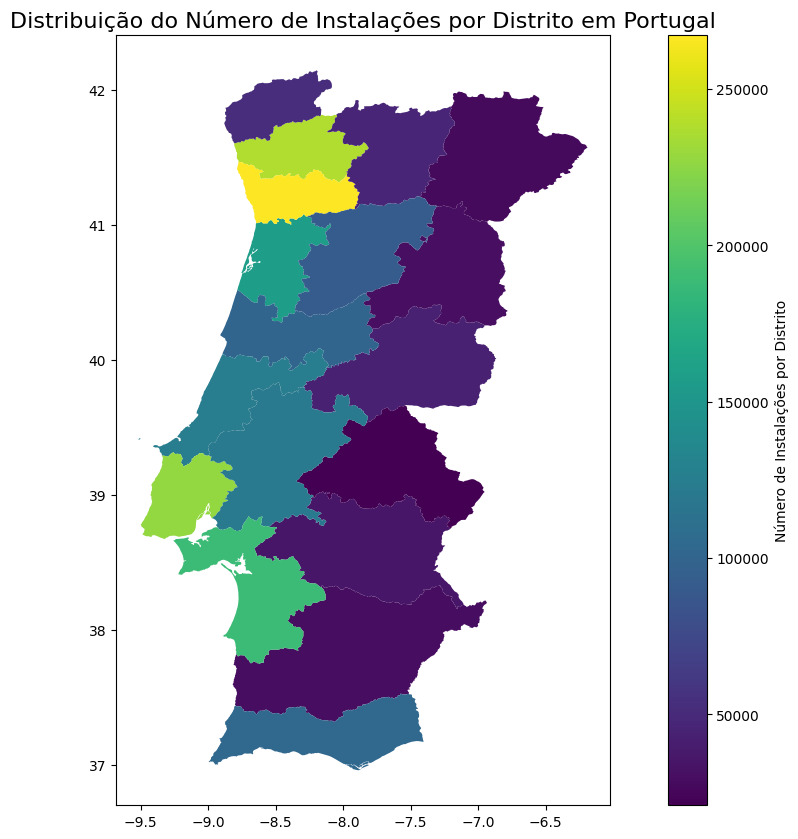

In [41]:
# Plotar o mapa com um gradiente para o número de instalações
plt.figure(figsize=(12, 8))

# Plotando o mapa e colorindo pelos números de instalações
# 'Número de instalacões' deve ser a coluna que contém os valores
# Use 'viridis' para um gradiente de cores ou qualquer outro que preferir
mapa_pt.plot(column='Número de instalacões', 
             cmap='viridis', 
             legend=True, 
             figsize=(15, 10), 
             legend_kwds={'label': "Número de Instalações por Distrito", 'orientation': "vertical"})

# Adicionar título
plt.title("Distribuição do Número de Instalações por Distrito em Portugal", fontsize=16)

# Exibir o mapa
plt.show()

# Evolução do Número de Instalações por Região para Autoconsumo em PT (2022-2024)

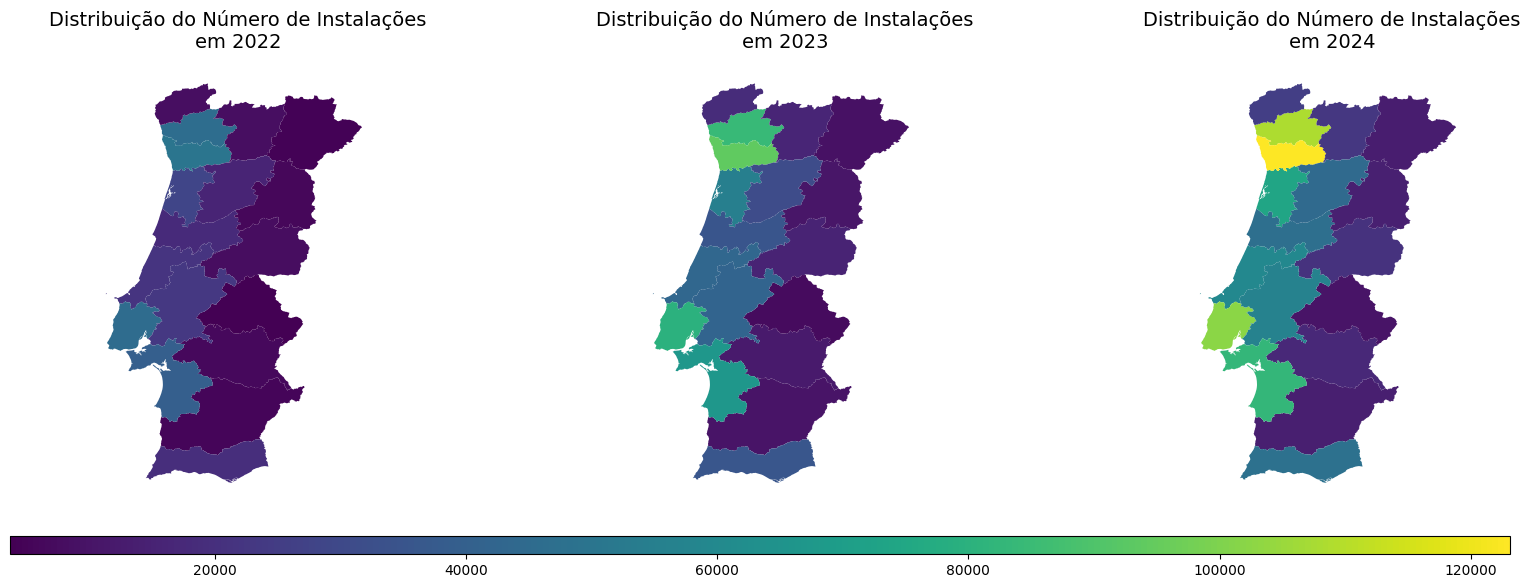

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')

# Criar a coluna 'Ano' a partir da coluna 'Trimestre'
dados['Ano'] = dados['Trimestre'].str[:4].astype(int)

# Agrupar os dados por 'Distrito' e 'Ano', somando o número de instalações
tabela_instalacoes = dados.groupby(['Distrito', 'Ano'])['Número de instalacões'].sum().reset_index()

# Carregar o shapefile de Portugal (ajustar o caminho conforme necessário)
mapa_pt = gpd.read_file('./pt.json')

# Se o nome da coluna no shapefile não for 'Distrito', renomeie para 'Distrito'
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})

# Calcular o valor mínimo e máximo para as instalações em todos os anos
min_value = tabela_instalacoes['Número de instalacões'].min()
max_value = tabela_instalacoes['Número de instalacões'].max()

# Agora vamos criar uma função para gerar os mapas por ano
def plot_map_for_year(year, ax, norm, cmap):
    # Filtrar os dados para o ano desejado
    df_ano = tabela_instalacoes[tabela_instalacoes['Ano'] == year]
    
    # Unir o DataFrame de instalações com o shapefile com base no distrito
    mapa_ano = mapa_pt.merge(df_ano, on='Distrito', how='left')

    # Calcular as cores usando a normalização
    colors = [cmap(norm(val)) for val in mapa_ano['Número de instalacões']]

    # Plotar o mapa com o gradiente de cores
    mapa_ano.plot(color=colors, legend=False, ax=ax)
    
    # Adicionar título
    ax.set_title(f"Distribuição do Número de Instalações\nem {year}", fontsize=14)
    ax.set_axis_off()  # Ocultar os eixos para um mapa mais limpo
    
    # Ajuste manual dos limites para remover o espaço em branco
    ax.set_xlim([-9.6, -6])  # Limites ajustados para focar em Portugal continental
    ax.set_ylim([36.5, 42.5])  # Limites ajustados para focar em Portugal continental
    ax.set_aspect('equal')  # Manter proporção correta do mapa

# Criar a figura com 3 subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normalização da escala para todos os mapas
norm = mpl.colors.Normalize(vmin=min_value, vmax=max_value)
cmap = mpl.cm.viridis

# Gerar os mapas para os anos de 2022, 2023 e 2024
plot_map_for_year(2022, axes[0], norm, cmap)
plot_map_for_year(2023, axes[1], norm, cmap)
plot_map_for_year(2024, axes[2], norm, cmap)

# Criar a barra de cores (legend) manualmente abaixo dos mapas
cbar_ax = fig.add_axes([0.125, 0.05, 0.75, 0.03])  # Posição da barra de cores (ajustando a posição para ficar abaixo)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Nenhuma entrada real para a barra de cores
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

# Ajustar o layout manualmente para evitar sobreposição e colocar a barra de cores
plt.subplots_adjust(hspace=0.3)  # Ajuste do espaçamento entre os gráficos e a barra de cores

# Exibir os mapas lado a lado com a barra de cores abaixo
plt.show()


# Evolução do Número Total de Instalações para Autoconsumo em PT 

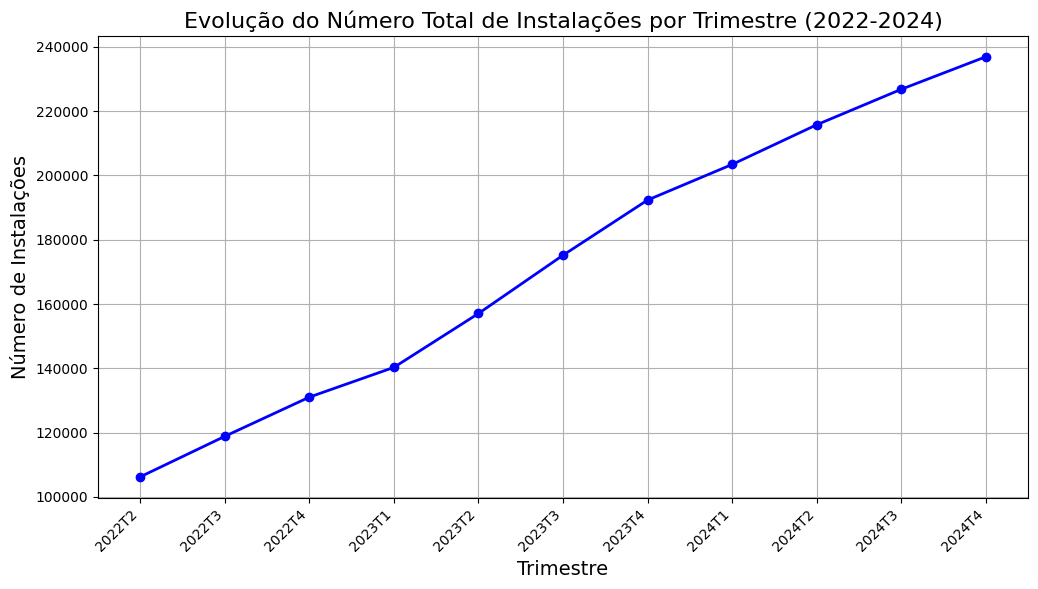

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')

# Agrupar os dados por 'Trimestre', somando o número de instalações
tabela_instalacoes_trimestre = dados.groupby('Trimestre')['Número de instalacões'].sum().reset_index()

# Filtrar os últimos 3 anos (2022, 2023, 2024)
tabela_instalacoes_trimestre = tabela_instalacoes_trimestre[tabela_instalacoes_trimestre['Trimestre'].str[:4].isin(['2022', '2023', '2024'])]

# Ordenar os trimestres corretamente
tabela_instalacoes_trimestre = tabela_instalacoes_trimestre.sort_values(by='Trimestre')

# Plotar o gráfico de evolução do número total de instalações por trimestre
plt.figure(figsize=(12, 6))
plt.plot(tabela_instalacoes_trimestre['Trimestre'], tabela_instalacoes_trimestre['Número de instalacões'], marker='o', color='b', linestyle='-', linewidth=2)

# Melhorar a legibilidade do eixo X
plt.xticks(rotation=45, ha='right')

# Adicionar título e rótulos aos eixos
plt.title('Evolução do Número Total de Instalações por Trimestre (2022-2024)', fontsize=16)
plt.xlabel('Trimestre', fontsize=14)
plt.ylabel('Número de Instalações', fontsize=14)
plt.grid(True)

# Exibir o gráfico
plt.show()


Observa-se um aumento no número de instalações praticamente linear